In [ ]:
## 1대1 영상 가져오면 초당 몇장씩 이미지로 변환해서 데이터 세트 만들어주는 코드

import cv2
from pathlib import Path
from datetime import datetime

# =========================
# 사용자 설정
# =========================
VIDEO_PATH = "carrot2.mp4"
N = 200                      # 저장할 이미지 장수
INTERVAL_SEC = 0.5          # 0.5초마다 1장
OUTPUT_ROOT = "frames"      # 결과 저장 상위 폴더
IMG_SIZE = 640              # 640x640

# =========================
# 출력 폴더 생성
# =========================
now_str = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = Path(OUTPUT_ROOT) / f"carrot_frames_{now_str}"
output_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 비디오 열기
# =========================
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError(f"비디오를 열 수 없습니다: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration_sec = frame_count / fps if fps > 0 else 0

print(f"[INFO] video: {VIDEO_PATH}")
print(f"[INFO] fps: {fps}")
print(f"[INFO] frame_count: {frame_count}")
print(f"[INFO] duration: {duration_sec:.2f} sec")
print(f"[INFO] output_dir: {output_dir}")

# =========================
# 0.5초마다 프레임 저장
# =========================
saved_count = 106

for i in range(N):
    target_time_sec = i * INTERVAL_SEC

    if target_time_sec > duration_sec:
        print("[INFO] 비디오 길이를 초과해서 중단합니다.")
        break

    # 해당 시간 위치로 이동
    cap.set(cv2.CAP_PROP_POS_MSEC, target_time_sec * 1000)

    ret, frame = cap.read()
    if not ret:
        print(f"[WARN] {target_time_sec:.2f}s 프레임을 읽지 못했습니다.")
        break

    # 640x640 리사이즈
    frame_resized = cv2.resize(frame, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    # 저장
    save_path = output_dir / f"frame_{saved_count:04d}_{target_time_sec:.1f}s.jpg"
    cv2.imwrite(str(save_path), frame_resized)

    saved_count += 1

cap.release()

print(f"[DONE] 저장 완료: {saved_count}장")
print(f"[DONE] 저장 위치: {output_dir}")

[INFO] video: carrot2.mp4
[INFO] fps: 24.0
[INFO] frame_count: 1609
[INFO] duration: 67.04 sec
[INFO] output_dir: frames\carrot_frames_20260609_223732
[INFO] 비디오 길이를 초과해서 중단합니다.
[DONE] 저장 완료: 241장
[DONE] 저장 위치: frames\carrot_frames_20260609_223732


In [ ]:
## 폴더내 이미지를 클래스 별로 0부터 카운트해서 이미지 재정렬 해주는 코드

from pathlib import Path

# =========================
# 사용자 설정
# =========================
TARGET_DIR = "frames/carrot_frames_20260609_222913"  # 이미지가 들어있는 폴더
NEW_PREFIX = "big_carrot"

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# =========================
# 이미지 파일 목록 가져오기
# =========================
target_dir = Path(TARGET_DIR)

if not target_dir.exists():
    raise FileNotFoundError(f"폴더가 없습니다: {target_dir}")

image_files = sorted([
    p for p in target_dir.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
])

print(f"[INFO] 이미지 개수: {len(image_files)}")

# =========================
# 이름 충돌 방지를 위해 임시 이름으로 먼저 변경
# =========================
temp_files = []

for i, img_path in enumerate(image_files):
    temp_path = target_dir / f"__temp_rename_{i:04d}{img_path.suffix.lower()}"
    img_path.rename(temp_path)
    temp_files.append(temp_path)

# =========================
# 최종 이름으로 변경
# =========================
for i, temp_path in enumerate(temp_files):
    new_name = f"{NEW_PREFIX}_{i:04d}{temp_path.suffix.lower()}"
    new_path = target_dir / new_name

    temp_path.rename(new_path)
    print(f"{temp_path.name} -> {new_path.name}")

print("[DONE] 파일명 변경 완료")

[INFO] 이미지 개수: 240
__temp_rename_0000.jpg -> big_carrot_0000.jpg
__temp_rename_0001.jpg -> big_carrot_0001.jpg
__temp_rename_0002.jpg -> big_carrot_0002.jpg
__temp_rename_0003.jpg -> big_carrot_0003.jpg
__temp_rename_0004.jpg -> big_carrot_0004.jpg
__temp_rename_0005.jpg -> big_carrot_0005.jpg
__temp_rename_0006.jpg -> big_carrot_0006.jpg
__temp_rename_0007.jpg -> big_carrot_0007.jpg
__temp_rename_0008.jpg -> big_carrot_0008.jpg
__temp_rename_0009.jpg -> big_carrot_0009.jpg
__temp_rename_0010.jpg -> big_carrot_0010.jpg
__temp_rename_0011.jpg -> big_carrot_0011.jpg
__temp_rename_0012.jpg -> big_carrot_0012.jpg
__temp_rename_0013.jpg -> big_carrot_0013.jpg
__temp_rename_0014.jpg -> big_carrot_0014.jpg
__temp_rename_0015.jpg -> big_carrot_0015.jpg
__temp_rename_0016.jpg -> big_carrot_0016.jpg
__temp_rename_0017.jpg -> big_carrot_0017.jpg
__temp_rename_0018.jpg -> big_carrot_0018.jpg
__temp_rename_0019.jpg -> big_carrot_0019.jpg
__temp_rename_0020.jpg -> big_carrot_0020.jpg
__temp_rename_0

In [ ]:
# 폴더내 txt파일내 ID가 0으로 통일되어 있다면 이 코드를 이용해서 ID 수정 가능

from pathlib import Path

# =========================
# 사용자 설정
# =========================
LABEL_DIR = "big_carrot/aa"   # txt 파일들이 들어있는 폴더 경로
NEW_CLASS_ID = 7       # 바꾸고 싶은 클래스 번호

# =========================
# 라벨 파일 처리
# =========================
label_dir = Path(LABEL_DIR)

if not label_dir.exists():
    raise FileNotFoundError(f"폴더가 없습니다: {label_dir}")

txt_files = sorted(label_dir.glob("*.txt"))

print(f"[INFO] txt 파일 개수: {len(txt_files)}")
print(f"[INFO] 변경할 class id: {NEW_CLASS_ID}")

for txt_path in txt_files:
    new_lines = []

    with open(txt_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()

        # 빈 줄은 유지
        if not line:
            new_lines.append("")
            continue

        parts = line.split()

        # YOLO 라벨은 보통 5개: class x y w h
        if len(parts) < 5:
            print(f"[WARN] 형식 이상, 건너뜀: {txt_path.name} -> {line}")
            new_lines.append(line)
            continue

        # 맨 앞 class id만 변경
        parts[0] = str(NEW_CLASS_ID)

        new_lines.append(" ".join(parts))

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write("\n".join(new_lines) + "\n")

    print(f"[OK] {txt_path.name}")

print("[DONE] 모든 txt 라벨 class id 변경 완료")

[INFO] txt 파일 개수: 227
[INFO] 변경할 class id: 3
[OK] big_carrot_0000.txt
[OK] big_carrot_0001.txt
[OK] big_carrot_0002.txt
[OK] big_carrot_0003.txt
[OK] big_carrot_0004.txt
[OK] big_carrot_0005.txt
[OK] big_carrot_0006.txt
[OK] big_carrot_0007.txt
[OK] big_carrot_0008.txt
[OK] big_carrot_0009.txt
[OK] big_carrot_0010.txt
[OK] big_carrot_0011.txt
[OK] big_carrot_0012.txt
[OK] big_carrot_0013.txt
[OK] big_carrot_0014.txt
[OK] big_carrot_0015.txt
[OK] big_carrot_0016.txt
[OK] big_carrot_0017.txt
[OK] big_carrot_0018.txt
[OK] big_carrot_0019.txt
[OK] big_carrot_0020.txt
[OK] big_carrot_0021.txt
[OK] big_carrot_0022.txt
[OK] big_carrot_0023.txt
[OK] big_carrot_0024.txt
[OK] big_carrot_0025.txt
[OK] big_carrot_0026.txt
[OK] big_carrot_0027.txt
[OK] big_carrot_0028.txt
[OK] big_carrot_0029.txt
[OK] big_carrot_0030.txt
[OK] big_carrot_0031.txt
[OK] big_carrot_0032.txt
[OK] big_carrot_0033.txt
[OK] big_carrot_0034.txt
[OK] big_carrot_0035.txt
[OK] big_carrot_0036.txt
[OK] big_carrot_0037.txt
[OK] 

In [5]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

import INUVisionLib as ivl

print("\n라이브러리 로드")


라이브러리 로드


[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 40% / X: 254~593, Y: 144~336)
✅ 레이저 파워 설정 완료: 250
✅ Disparity Shift 설정 완료: 0
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.2m, 최대: 0.8m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON
🔥 센서 안정화 중... (30 프레임 대기)


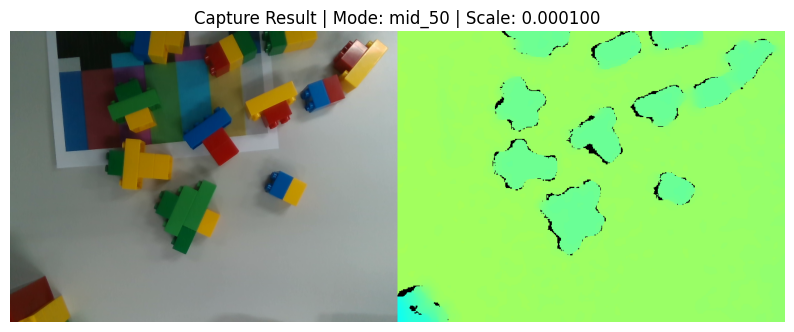

✅ 카메라 스트리밍 안전 종료 완료.


In [7]:
# 카메라 연결 확인
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0]

# 8비트 RGB 이미지, 16비트 뎁스, 인트린직, 뎁스 스케일 출력
# 카메라 모드 별로 설정 변경 가능

color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=True
)

color_img_bgr = cv2.cvtColor(color_rgb.copy(), cv2.COLOR_RGB2BGR)

In [13]:
import numpy as np
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import sys
import os
from matplotlib import pyplot as plt

# 시각화를 위한 함수 선언
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))
    
# SAM 모델 Load
sys.path.append("..")
from segment_anything import sam_model_registry, SamPredictor

# pth 파일은 hugging face에서 다운로드 가능합니다 
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

# 이미지와 label 위치 지정
image_dir = ""
label_dir = ""

# 이미지 파일의 이름 가져오기
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

# 반복문을 통해 이미지 파일과 label 파일의 정보 SAM에 넣기
for i, image_file in enumerate(image_files):
	# 매 이미지 마다 list 초기화
    input_boxes = []
    image_path = os.path.join(image_dir, image_file)
    label_file = os.path.splitext(image_file)[0] + ".txt"
    label_path = os.path.join(label_dir, label_file)
    if os.path.exists(label_path):
        image = cv2.imread(image_path)
        height, width, _ = image.shape
        predictor.set_image(image)
        with open(label_path, 'r') as f:
            for line in f.readlines():
            	# label 정보를 이용해 class_id와 박스 추출(좌상단 & 우하단 값)
                class_id, x_center, y_center, box_width, box_height = map(float, line.strip().split())
                x_center *= width
                y_center *= height
                box_width *= width
                box_height *= height
                x_min = int(x_center - (box_width / 2))
                y_min = int(y_center - (box_height / 2))
                x_max = int(x_center + (box_width / 2))
                y_max = int(y_center + (box_height / 2))
                input_boxes.append([x_min, y_min, x_max, y_max])
        input_boxes_tensor = torch.tensor(input_boxes, dtype=torch.float, device='cuda')            
        transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes_tensor, image.shape[:2])
		
        # 박스 내부의 객체 mask 추출
        masks, _, _ = predictor.predict_torch(
            point_coords=None,
            point_labels=None,
            boxes=transformed_boxes,
            multimask_output=False,
        )
        # 출력값 시각화 
        for mask in masks:
            show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
        for box in input_boxes_tensor:
            show_box(box.cpu().numpy(), plt.gca())
    else:
        not_found.append(label_path)

FileNotFoundError: [Errno 2] No such file or directory: 'sam_vit_h_4b8939.pth'

In [12]:
# %pwd
# !python -m pip install git+https://github.com/facebookresearch/segment-anything.git

  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\Public\Documents\ESTsoft\CreatorTemp\pip-req-build-fp_de7y_'



  Cloning https://github.com/facebookresearch/segment-anything.git to c:\users\public\documents\estsoft\creatortemp\pip-req-build-fp_de7y_
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


In [ ]:
# import urllib.request
# import os

# url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
# filename = "sam_vit_h_4b8939.pth"

# if not os.path.exists(filename):
#     print("⏳ SAM 가중치 파일 다운로드 중... (약 2.4GB, 시간이 조금 걸립니다!)")
#     urllib.request.urlretrieve(url, filename)
#     print("✅ 다운로드 완료!")
# else:
#     print("✅ 파일이 이미 존재합니다.")